Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Distribution of the sample AUC (Area Under the receiver operating characteristic Curve) and percentile confidence intervals for the population AUC computed via bootstrapping.\
Topics and relevant videos: [Random sampling and the bias](https://youtu.be/iPTTn-hPg_0?si=oycOmm43MwWaNa3h), [bootstrap percentile confidence intervals](https://youtu.be/EVLST4nPkXA?si=A8XLEbiOpjP3j3JO), [evaluation of classification models](https://www.youtube.com/watch?v=wYflzBlGigM)

Author: Carlos Fernandez-Granda

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

data = np.load('../data/auc_confidence_intervals.npz')

# Extract the individual arrays
labels = data['labels']
est_prob = data['est_prob']

population_auc = roc_auc_score(labels, est_prob)
print(f"AUC: {population_auc:.4f}")
N = len(labels)
print("Population N:", N)

AUC: 0.8478
Population N: 2045


In [2]:
n_samples = 100
n_iterations = 1_000

sample_aucs = []

# Random seed for reproducibility
rng = np.random.default_rng(seed=2026)

for _ in range(n_iterations):
    # Randomly select 50 indices without replacement
    idx = rng.choice(N, size=n_samples, replace=False)
    
    # Check if both classes (0 and 1) are present in the sample
    # (roc_auc_score requires at least one positive and one negative sample)
    if len(np.unique(labels[idx])) > 1:
        auc_i = roc_auc_score(labels[idx], est_prob[idx])
        sample_aucs.append(auc_i)

sample_aucs = np.array(sample_aucs)


Mean sample AUC: 0.8477
Population AUC: 0.8478


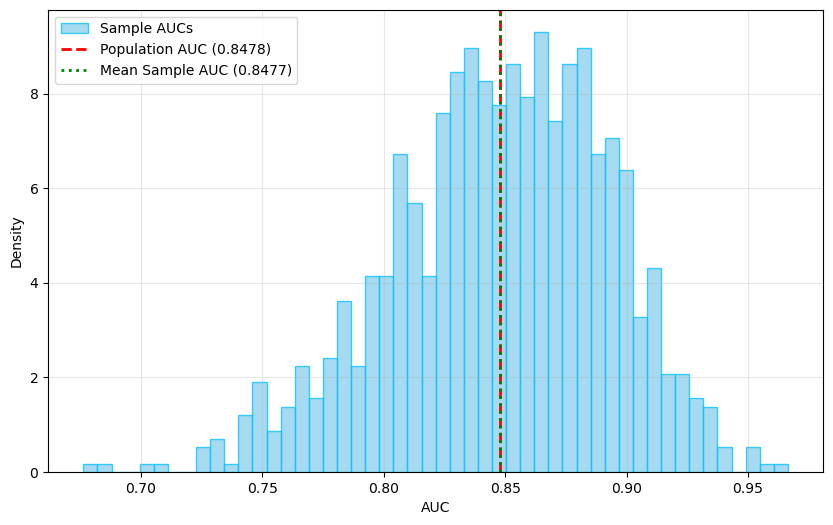

In [3]:
# Compute mean of estimated AUCs
mean_sample_auc = np.mean(sample_aucs)
bias = mean_sample_auc - population_auc

print(f"Mean sample AUC: {mean_sample_auc:.4f}")
print(f"Population AUC: {population_auc:.4f}")

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_aucs, bins=50, density=True, alpha=0.75, color='skyblue', edgecolor='deepskyblue', label='Sample AUCs')
plt.axvline(population_auc, color='red', linestyle='--', linewidth=2, label=f'Population AUC ({population_auc:.4f})')
plt.axvline(mean_sample_auc, color='green', linestyle=':', linewidth=2, label=f'Mean Sample AUC ({mean_sample_auc:.4f})')

plt.xlabel('AUC')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
n_CIs = 200      # Number of CIs to construct
n_bootstrap = 1_000    # Bootstrap resamples per CI
alpha = 0.05             # 95% Confidence Interval

ci_lowers = np.zeros(n_CIs)
ci_uppers = np.zeros(n_CIs)
sample_means = np.zeros(n_CIs)

rng = np.random.default_rng(seed=42)

for i in range(n_CIs):
    # Sample of n:=50 from the population 
    sample_idx = rng.choice(N, size=n_samples, replace=True)
    sample_labels = labels[sample_idx]
    sample_probs = est_prob[sample_idx]
    
    # Resample to obtain bootstrap dataset
    boot_aucs = []
    for _ in range(n_bootstrap):
        boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
        boot_y = sample_labels[boot_idx]
        
        # Check that both classes exist in the bootstrap dataset
        if len(np.unique(boot_y)) > 1:
            auc_b = roc_auc_score(boot_y, sample_probs[boot_idx])
            boot_aucs.append(auc_b)
            
    boot_aucs = np.array(boot_aucs)
    
    # Compute Percentile CI boundaries (2.5th and 97.5th percentiles)
    ci_lowers[i] = np.percentile(boot_aucs, 100 * (alpha / 2))
    ci_uppers[i] = np.percentile(boot_aucs, 100 * (1 - alpha / 2))
    sample_means[i] = np.mean(boot_aucs)

Empirical coverage probability: 95.5000%


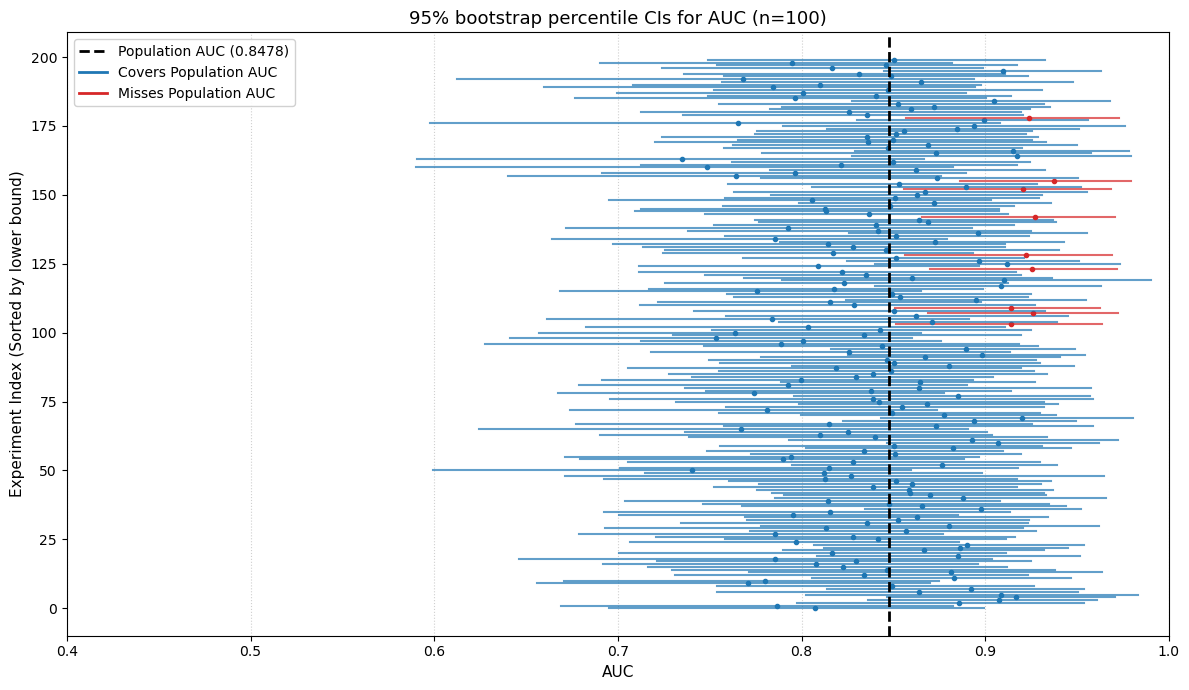

In [5]:
# Coverage probability
# Check which intervals contain the population AUC
contains_pop = (ci_lowers <= population_auc) & (population_auc <= ci_uppers)
coverage_prob = np.mean(contains_pop)

print(f"Empirical coverage probability: {coverage_prob * 100:.4f}%")

# Visualization of Confidence Intervals
fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(n_CIs)

# Color-code intervals (blue = covers population AUC, red = misses)
colors = ['#1f77b4' if c else '#d62728' for c in contains_pop]

# Draw CIs
for i in range(n_CIs):
    ax.plot([ci_lowers[i], ci_uppers[i]], [y_pos[i], y_pos[i]], 
            color=colors[i], alpha=0.7, linewidth=1.5)
    ax.plot(sample_means[i], y_pos[i], marker='o', markersize=3, color=colors[i])

# Population AUC baseline
ax.axvline(population_auc, color='black', linestyle='--', linewidth=2, 
           label=f'Population AUC ({population_auc:.4f})')

# Dummy lines for crisp legend entries
ax.plot([], [], color='#1f77b4', linewidth=2, label=f'Covers Population AUC')
ax.plot([], [], color='#d62728', linewidth=2, label=f'Misses Population AUC')

# Styling
ax.set_title(f'95% bootstrap percentile CIs for AUC (n={n_samples})', 
             fontsize=13)
ax.set_xlabel('AUC', fontsize=11)
ax.set_ylabel('Experiment Index (Sorted by lower bound)', fontsize=11)
ax.set_xlim(0.4, 1.0)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()